## Notebook 2 – Distance-Based Machine Learning (K-Nearest Neighbours)

### 1. EXPLORATORY DATA ANALYSIS (EDA) + FEATURE INSIGHT

#### Importing libraries

In [141]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, classification_report, confusion_matrix)
from sklearn.preprocessing import (LabelEncoder, LabelBinarizer, OrdinalEncoder,
                                    StandardScaler, MinMaxScaler)
from sklearn.neighbors import KNeighborsClassifier

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

np.random.seed(24)
# stores the randomely generated data in seed 24

In [4]:
# Importing dataframe from Notebook 1

df = pd.read_csv('CTR_Prediction_Dataframe.csv').drop('Unnamed: 0', axis = 1)

In [5]:
df.head()

,ad_budget,impressions,click_history,user_engagement_score,time_on_site,device_score,clicked
0,1398.763652,50100.895666,27,0.698608,40.747007,0,0
1,768.989964,50610.176940,28,0.352786,71.475851,1,0
2,905.115892,46363.857264,42,0.535134,71.385886,0,0
3,702.756884,67688.402327,4,0.275047,63.096945,1,0
4,678.755123,22218.359496,45,0.816535,40.374703,1,0


In [6]:
df.isnull().sum()

ad_budget                0
impressions              0
click_history            0
user_engagement_score    0
time_on_site             0
device_score             0
clicked                  0
dtype: int64

In [7]:
df.nunique()

ad_budget                5000
impressions              5000
click_history              50
user_engagement_score    5000
time_on_site             5000
device_score                2
clicked                     2
dtype: int64

In [11]:
print('\nDataframe Structure\n')
df.info()


Dataframe Structure

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ad_budget              5000 non-null   float64
 1   impressions            5000 non-null   float64
 2   click_history          5000 non-null   int64  
 3   user_engagement_score  5000 non-null   float64
 4   time_on_site           5000 non-null   float64
 5   device_score           5000 non-null   int64  
 6   clicked                5000 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 273.6 KB


In [12]:
print('\nSummary Statistics\n')
df.describe()


Summary Statistics



,ad_budget,impressions,click_history,user_engagement_score,time_on_site,device_score,clicked
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,995.756272,49868.484588,24.660800,0.501541,60.127379,0.688000,0.116800
std,295.239804,14912.159593,14.396847,0.151293,19.971454,0.463356,0.321214
min,-21.458309,-4518.087037,0.000000,-0.046874,-9.760607,0.000000,0.000000
25%,796.705941,39833.664582,12.000000,0.400175,46.563899,0.000000,0.000000
50%,994.610605,49675.658556,25.000000,0.497377,59.810107,1.000000,0.000000
75%,1198.778488,59595.314140,37.000000,0.604109,73.922158,1.000000,0.000000
max,2298.900792,104357.414301,49.000000,1.049246,128.133075,1.000000,1.000000


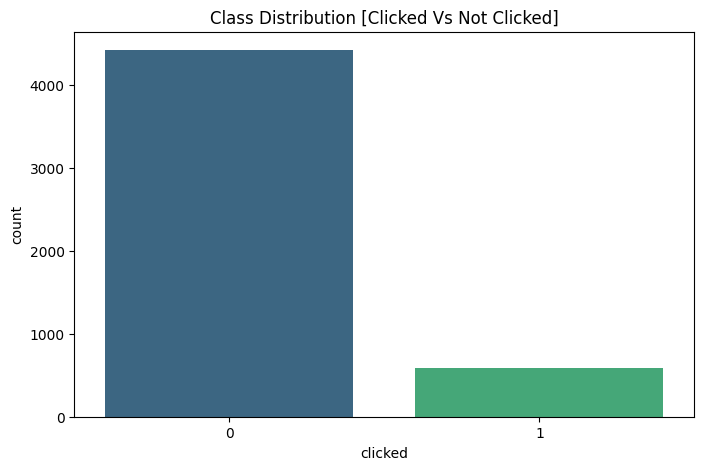

In [18]:
plt.figure(figsize = (8,5))

sns.countplot(data = df, x = 'clicked', palette = 'viridis')

plt.title('Class Distribution [Clicked Vs Not Clicked]')
plt.show();

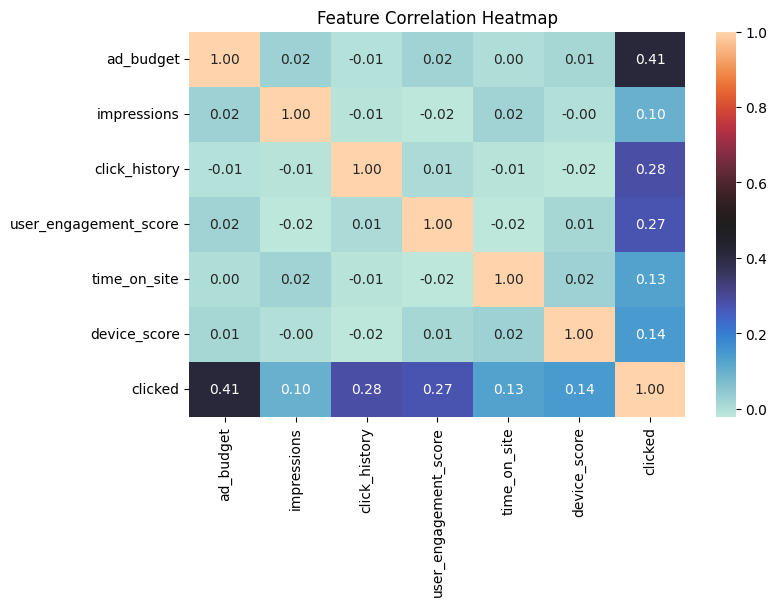

In [33]:
corr_df = df.corr()

plt.figure(figsize = (8,5))

sns.heatmap(corr_df, annot = True, cmap = 'icefire', fmt = '.2f')

plt.title('Feature Correlation Heatmap')
plt.show();

### 2. THEORY: WHY LOGISTIC RIGRESSION STRUGGLES

_Logistic Regression_ creates a rigid, straight linear decision boundary.
If data classes from overlapping clusters or spiral shapes, a straight line will fail.
**KNN** creates flexible, complex, non-linear boundaries by looking at local neighborhoods.
This makes KNN highly suitable for irregular, complex datasets where linear assumptions break.

### 3. VECTOR CALCULATIONS: DISTANCE-BASED LEARNING

In [46]:
# Defining two arbitrary data coordinate points

pointA = np.array([3,5])
pointB = np.array([7,9])

# Euclidean Distance (L2 Norm) - Straight line distance
# Mathematical Formula: sqrt((x2-x1)² + (y2-y1)²)

euclidean_dist = np.linalg.norm(pointA - pointB)

print(f'Euclidean distance: {euclidean_dist:.4f}\n')


# Manhattan Distance (L1 Norm) - Grid/City block distance
# Mathematical Formula: |x2-x1| + |y2-y1|

manhattan_dist = np.sum(np.abs(pointA - pointB))

print(f'Manhattan Distance: {manhattan_dist:.4f}')

Euclidean distance: 5.6569

Manhattan Distance: 8.0000


### 4. EDUCATIONAL SANDBOX: CATEGORICAL ENCODING TECHNIQUES

In [59]:
devices = ["Mobile", "Desktop", "Tablet", "Mobile"]

# Label Encoder (Encodes target categories sequentially: 0, 1, 2)
encoder = LabelEncoder()

print('Label Encoder:', encoder.fit_transform(devices), '\n')

# Label Binarizer (Creates a One-Hot encoded binary matrix)
binarizer = LabelBinarizer()

print('Label Binarizer Matrix:\n', binarizer.fit_transform(devices), '\n')


priorities = pd.DataFrame({
    'campaign_priority': ['High', 'Low', 'Medium', 'High']
})

# Ordinal Encoder (Preserves specific step-by-step structural order)
oe = OrdinalEncoder(categories = [['Low', 'Medium', 'High']])

print('Ordinal Encoder:\n', oe.fit_transform(priorities))

Label Encoder: [1 0 2 1] 

Label Binarizer Matrix:
 [[0 1 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]] 

Ordinal Encoder:
 [[2.]
 [0.]
 [1.]
 [2.]]


### 5. TRAIN / TEST SPLIT (STRATIFIED)

In [67]:
X = df.drop('clicked', axis = 1)

y = df['clicked']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 24,
    stratify = y
    # stratify = y ensures that training and testing sets have the exact same percentage of clicks as the original dataset
)

In [73]:
print(f'The shape of X_train {X_train.shape} matches the shape of y_train {y_train.shape}, while the shape of X_test {X_test.shape} matches the shape  of y_test {y_test.shape}.')

The shape of X_train (4000, 6) matches the shape of y_train (4000,), while the shape of X_test (1000, 6) matches the shape  of y_test (1000,).


In [81]:
print('y_train Stratified Share:\n', y_train.value_counts(normalize = True), '\n')

print('y_test Stratified Share:\n', y_test.value_counts(normalize = True))

y_train Stratified Share:
 clicked
0    0.88325
1    0.11675
Name: proportion, dtype: float64 

y_test Stratified Share:
 clicked
0    0.883
1    0.117
Name: proportion, dtype: float64


### 6. KNN PIPELINES

**K-Nearest Neighbors (KNN)** model is a simple, intuitive, and effective machine learning algorithm used for both classification (predicting a category) and regression (predicting a number). It assumes that similar data points exist close to each other in geometric space.

Because KNN calculates geometric distances (like the Euclidean distance formula discussed earlier), it is highly sensitive to the scale of features. If one feature ranges from 1 to 10 and another ranges from 1 to 1,000, the larger feature will completely dominate the distance calculation. 

Scalers fix this.

StandardScaler(): Converts features so they have a mean of 0 and a standard deviation of 1. It centers the data.

MinMaxScaler(): Compresses or stretches features so all values fall strictly between a minimum of 0 and a maximum of 1.

In [125]:
knn_sc_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors = 5))
    # n_neighbors = 5 means the model will look at its 5 closest neighbors and take a majority vote to assign a label
])

knn_mm_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', KNeighborsClassifier(n_neighbors = 5))
])

knn_sc_pipe.fit(X_train, y_train)
knn_mm_pipe.fit(X_train, y_train)

print('StandardScaled Test Score:', knn_sc_pipe.score(X_test, y_test))
print('MinMaxScaled Test Score:',knn_mm_pipe.score(X_test, y_test))

StandardScaled Test Score: 0.969
MinMaxScaled Test Score: 0.958


Above results prove that for the marketing dataframe, standardising around the mean and variance retains a better spatial layout for KNN than compressing the data strictly between 0 and 1.

### 7. UNIFORM BASELINE KNN CLASSIFICATION

In [110]:
# Finding the Optimal k using the winning StandardScaler

f1_scores = []

ks = range(1,31)

for k in ks:
    knn_tuned_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors = k))
    ])

    knn_tuned_pipe.fit(X_train, y_train)

    knn_tuned_pred = knn_tuned_pipe.predict(X_test)

    f1_scores.append(f1_score(y_test, knn_tuned_pred))

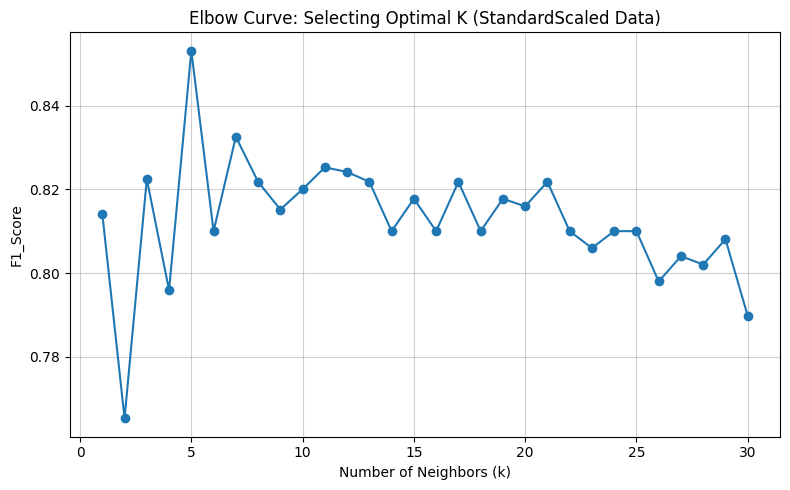

In [117]:
# Plotting the Elbow Curve

plt.figure(figsize = (8,5))

plt.plot(ks, f1_scores, marker = 'o')

plt.title('Elbow Curve: Selecting Optimal K (StandardScaled Data)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('F1_Score')

plt.grid(alpha = 0.6,)
plt.tight_layout()
plt.show();

In [122]:
optimal_k = ks[np.argmax(f1_scores)]

print('The mathematically optimal number of neighbor (k):', optimal_k)

The mathematically optimal number of neighbor (k): 5


In [126]:
# Optimal k value comes to 5 which is already used in knn_sc_pipe

knn_sc_pred = knn_sc_pipe.predict(X_test)

print('Classification Report:\n', classification_report(y_test, knn_sc_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       883
           1       0.96      0.77      0.85       117

    accuracy                           0.97      1000
   macro avg       0.96      0.88      0.92      1000
weighted avg       0.97      0.97      0.97      1000



### 8. ADVANCED VARIANCE: WEIGHTED KNN

**Uniform KNN**: If K=1, the model overfits. If K is too large, the majority class completely dominates the voting block.

**Weighted KNN**: Closer neighbors get massive voting weights, while distant neighbors get tiny fractional votes. This makes the model highly robust to larger values of K.

In [132]:
# Finding the Optimal k using the winning StandardScaler where KNN is weighed

f1_weighted_scores = []

ks = range(1,31)

for k in ks:
    knn_weighted_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(
            n_neighbors = k,
            weights = 'distance'
            # weights = 'distance' gives closer neighbors a stronger vote, while neighbors that are further away get a weaker vote.
        ))
    ])

    knn_weighted_pipe.fit(X_train, y_train)

    knn_weighted_pred = knn_weighted_pipe.predict(X_test)

    f1_weighted_scores.append(f1_score(y_test, knn_weighted_pred))

In [134]:
optimal_weighted_k = ks[np.argmax(f1_weighted_scores)]

print('The mathematically optimal number of neighbor (k) when k is weighted:', optimal_weighted_k)

The mathematically optimal number of neighbor (k) when k is weighted: 5


**Key takeaway**

Weighted K value still coming to 5 indicates that dataset could potentially have clean, dense data clusters with sharp boundaries. The 5 closest neighbors to any given test point are so close and uniform in their classification that adding distance penalties doesn't alter the majority vote. 

### 9. FINAL WEIGHTED KNN CLASSIFICATION

In [139]:
knn_optimal_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(
        n_neighbors = 5,
        weights = 'distance'
    ))
])

knn_optimal_pipe.fit(X_train, y_train)

knn_optimal_pred = knn_optimal_pipe.predict(X_test)

print('Classification Report:\n', classification_report(y_test, knn_optimal_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       883
           1       0.95      0.79      0.86       117

    accuracy                           0.97      1000
   macro avg       0.96      0.89      0.92      1000
weighted avg       0.97      0.97      0.97      1000



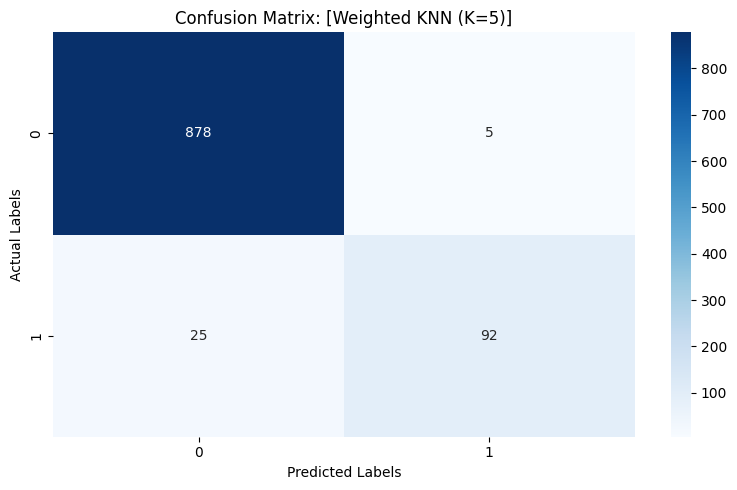

In [148]:
cm_knn = confusion_matrix(y_test, knn_optimal_pred)

plt.figure(figsize = (8,5))

sns.heatmap(cm_knn, annot = True, cmap = 'Blues', fmt = 'd')

plt.title('Confusion Matrix: [Weighted KNN (K=5)]')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.tight_layout()
plt.show();

In [151]:
# Probability Analysis: Raw confidence margins for the first 10 test records

print(knn_optimal_pipe.predict_proba(X_test[:10]))

[[1.         0.        ]
 [1.         0.        ]
 [1.         0.        ]
 [1.         0.        ]
 [1.         0.        ]
 [1.         0.        ]
 [1.         0.        ]
 [1.         0.        ]
 [0.58143924 0.41856076]
 [0.         1.        ]]


#### Final Classification Leaderboard

1. **Winning Model: Logistic Regression (L1-Tuned, C=166.81)(Notebook 1)**
   * Test Accuracy: 98.6%
   * Error Profile: 6 False Positives, 8 False Negatives
     
2. **Runner Up: Weighted K-Nearest Neighbours (K=5, StandardScaler)(Notebook 2)**
   * Test Accuracy: 97.0% (970 / 1000 correct predictions)
   * Error Profile: 5 False Positives, 25 False Negatives

#### Key Architectural Takeaways

* **The Linear Advantage:** Logistic Regression outperforms Weighted KNN by 1.6% in total accuracy. This indicates that a flat linear decision plane perfectly segments the high-performing ad campaigns without needing complex spatial clustering.
  
* **The Error Trade-off:** While KNN matches Logistic Regression on limiting False Positives (only 5 mistakes), it is far more conservative, missing 25 true conversion opportunities (False Negatives) compared to Logistic Regression's 8.

* **Production Recommendation:** Logistic Regression is the definitive choice for production deployment. Not only does it yield higher precision, but it avoids the severe memory footprint of KNN, which requires holding all 5,000 training rows in active memory to calculate distances on live web traffic.